In [8]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

repo_root = Path.cwd().parent
sys.path.append(str(repo_root))

# import local libraries
import src.utils.config as config
import src.proc.process_behavior_signals as pbs
# import proc.organize as org
import src.utils.data_io as dio
import src.utils.pdata_io as pdio
import numpy as np


# print(config.PROJECT_ROOT)
# print(config.RAW_BASE)
# print(config.PROC_BASE)

import sys
from pathlib import Path

CODE_BASE = Path(config.CODE_BASE).expanduser()
sys.path.append(str(CODE_BASE))

print("Added to path:", CODE_BASE)

# make the data dictionary which contains list of all animals and sessions and
# file names of videos h264 and mat files

data_root = config.RAW_BASE # this variable now contains the path to the raw data directory, which is defined in the config file. It is used to build the classical conditioning data dictionary using the dio.build_classical_conditioning_dict function. The resulting cc_data variable will contain the structured information about the animals, sessions, and file names for the classical conditioning experiments.
cc_data = dio.build_classical_conditioning_dict(data_root)

pdata_root = config.PROC_BASE # this variable now contains the path to the processed data directory, which is defined in the config file. It is used to build the processed data dictionary using the pdio.build_processed_data_dict function. The resulting pdata variable will contain the structured information about the animals, sessions, and file names for the processed data of the classical conditioning experiments.
print(data_root)
print(pdata_root)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Added to path: /home/nmldata2/ccaw/Python

DATA DIRECTORY NOT MOUNTED:
/mnt/data/Classical_Conditioning

/mnt/data/Classical_Conditioning
/mnt/pdata/Classical_Conditioning


In [12]:
animal = "NML_06"
date = "2026_01_14"

state_config = pbs.BehaviorStateConfig(
    analysis_hz=100,

    # Locomotion begins above 1 cm/s
    # and ends below 0.5 cm/s.
    move_on_cms=1.0,
    move_off_cms=0.5,

    # Remove very short movement events.
    min_move_s=0.10,

    # Join movement interruptions shorter than 300 ms.
    join_move_gaps_s=0.30,

    # Quiet-immobility definition.
    quiet_cms=0.25,
    min_quiet_s=1.0,
    join_quiet_gaps_s=0.10,

    # Analyze up to 5 seconds of pre-air immobility.
    pre_air_max_s=5.0,

    # First second after final locomotor offset.
    immediate_post_s=1.0,

    # Bout-specific sustained locomotion threshold.
    sustain_fraction=0.60,
    min_sustain_s=0.20,
)

(
    trial_summary_df,
    state_episodes_df,
    state_signals,
) = pbs.identify_behavior_states(
    animal=animal,
    date=date,
    cc_data=cc_data,
    state_config=state_config,
)

In [13]:
display(trial_summary_df.head())

,animal,date,phase,trial,air_on_s,air_off_s,air_duration_s,trial_forward_cm,pre_air_immobility_duration_s,air_on_immobility_duration_s,...,total_locomotion_during_air_s,initiation_total_s,sustained_locomotion_total_s,deceleration_total_s,immediate_post_run_duration_s,longer_quiet_immobility_duration_s,moving_at_air_on,valid_pre_air_immobility,no_locomotor_response,complex_trial
0,NML_06,2026_01_14,unknown,1,21.5932,35.4844,13.8912,36.040351,2.75,0.29,...,9.99,0.97,9.09,1.32,1.0,12.05,False,True,False,True
1,NML_06,2026_01_14,unknown,2,50.5714,59.1402,8.5688,35.135572,5.00,0.10,...,7.62,1.76,6.15,1.49,1.0,12.20,False,True,False,True
2,NML_06,2026_01_14,unknown,3,74.2266,79.4428,5.2162,34.984776,5.00,0.10,...,5.13,1.13,4.16,2.07,1.0,11.27,False,True,False,False
3,NML_06,2026_01_14,unknown,4,94.5292,103.1006,8.5714,35.110439,5.00,0.11,...,8.02,1.20,7.18,1.91,1.0,11.80,False,True,False,True
4,NML_06,2026_01_14,unknown,5,118.1864,124.7946,6.6082,35.009909,5.00,0.12,...,6.50,0.55,6.39,0.28,1.0,9.94,False,True,False,False


In [15]:
columns_to_view = [
    "animal",
    "date",
    "phase",
    "trial",
    "air_duration_s",
    "trial_forward_cm",
    "pre_air_immobility_duration_s",
    "air_on_immobility_duration_s",
    "air_to_locomotion_latency_s",
    "n_locomotor_bouts",
    "initiation_total_s",
    "sustained_locomotion_total_s",
    "deceleration_total_s",
    "continued_running_after_air_off_s",
    "immediate_post_run_duration_s",
    "longer_quiet_immobility_duration_s",
    "moving_at_air_on",
    "valid_pre_air_immobility",
    "no_locomotor_response",
    "complex_trial",
]

display(
    trial_summary_df[
        columns_to_view
    ]
)

,animal,date,phase,trial,air_duration_s,trial_forward_cm,pre_air_immobility_duration_s,air_on_immobility_duration_s,air_to_locomotion_latency_s,n_locomotor_bouts,initiation_total_s,sustained_locomotion_total_s,deceleration_total_s,continued_running_after_air_off_s,immediate_post_run_duration_s,longer_quiet_immobility_duration_s,moving_at_air_on,valid_pre_air_immobility,no_locomotor_response,complex_trial
0,NML_06,2026_01_14,unknown,1,13.8912,36.040351,2.75,0.29,0.29,5,0.97,9.09,1.32,1.39,1.0,12.05,False,True,False,True
1,NML_06,2026_01_14,unknown,2,8.5688,35.135572,5.00,0.10,0.10,3,1.76,6.15,1.49,1.78,1.0,12.20,False,True,False,True
2,NML_06,2026_01_14,unknown,3,5.2162,34.984776,5.00,0.10,0.10,1,1.13,4.16,2.07,2.23,1.0,11.27,False,True,False,False
3,NML_06,2026_01_14,unknown,4,8.5714,35.110439,5.00,0.11,0.11,2,1.20,7.18,1.91,2.27,1.0,11.80,False,True,False,True
4,NML_06,2026_01_14,unknown,5,6.6082,35.009909,5.00,0.12,0.12,1,0.55,6.39,0.28,0.72,1.0,9.94,False,True,False,False
5,NML_06,2026_01_14,unknown,6,6.8048,34.984776,5.00,0.22,0.22,1,0.72,6.46,1.23,1.82,1.0,9.08,False,True,False,False
6,NML_06,2026_01_14,unknown,7,7.3280,35.035041,1.53,0.16,0.16,1,1.37,7.64,0.45,2.29,1.0,11.79,False,True,False,False
7,NML_06,2026_01_14,unknown,8,6.0746,35.160705,5.00,0.11,0.11,1,0.48,5.78,1.94,2.22,1.0,1.15,False,True,False,False
8,NML_06,2026_01_14,unknown,9,7.4940,34.984776,0.00,0.09,0.09,1,1.11,7.81,2.16,3.66,1.0,4.54,False,False,False,False
9,NML_06,2026_01_14,unknown,10,5.0318,34.984776,5.00,0.08,0.08,2,1.13,3.40,2.13,2.06,1.0,6.07,False,True,False,True


In [16]:
display(state_episodes_df.head(30))

,animal,date,phase,trial,state,bout_number,onset_sample,offset_sample,onset_s,offset_s,duration_s,onset_relative_air_s,offset_relative_air_s,note
0,NML_06,2026_01_14,unknown,1,pre_air_immobility,NaN,94200,107950,18.84,21.59,2.75,-2.75,0.00,
1,NML_06,2026_01_14,unknown,1,air_on_immobility,NaN,107950,109400,21.59,21.88,0.29,0.00,0.29,
2,NML_06,2026_01_14,unknown,1,locomotor_initiation,1.0,109400,109450,21.88,21.89,0.01,0.29,0.30,ok
3,NML_06,2026_01_14,unknown,1,sustained_locomotion,1.0,109450,118400,21.89,23.68,1.79,0.30,2.09,ok
4,NML_06,2026_01_14,unknown,1,deceleration,1.0,118400,118650,23.68,23.73,0.05,2.09,2.14,ok
5,NML_06,2026_01_14,unknown,1,interbout_immobility,1.0,118650,121250,23.73,24.25,0.52,2.14,2.66,
6,NML_06,2026_01_14,unknown,1,sustained_locomotion,2.0,121250,124300,24.25,24.86,0.61,2.66,3.27,ok
7,NML_06,2026_01_14,unknown,1,deceleration,2.0,124300,125550,24.86,25.11,0.25,3.27,3.52,ok
8,NML_06,2026_01_14,unknown,1,interbout_immobility,2.0,125550,127600,25.11,25.52,0.41,3.52,3.93,
9,NML_06,2026_01_14,unknown,1,locomotor_initiation,3.0,127600,128000,25.52,25.60,0.08,3.93,4.01,no_clear_sustained_phase


In [17]:
trial_number = 1

display(
    state_episodes_df.loc[
        state_episodes_df["trial"] == trial_number,
        [
            "trial",
            "state",
            "bout_number",
            "onset_s",
            "offset_s",
            "duration_s",
            "onset_relative_air_s",
            "offset_relative_air_s",
            "note",
        ],
    ]
)

,trial,state,bout_number,onset_s,offset_s,duration_s,onset_relative_air_s,offset_relative_air_s,note
0,1,pre_air_immobility,NaN,18.84,21.59,2.75,-2.75,0.00,
1,1,air_on_immobility,NaN,21.59,21.88,0.29,0.00,0.29,
2,1,locomotor_initiation,1.0,21.88,21.89,0.01,0.29,0.30,ok
3,1,sustained_locomotion,1.0,21.89,23.68,1.79,0.30,2.09,ok
4,1,deceleration,1.0,23.68,23.73,0.05,2.09,2.14,ok
5,1,interbout_immobility,1.0,23.73,24.25,0.52,2.14,2.66,
6,1,sustained_locomotion,2.0,24.25,24.86,0.61,2.66,3.27,ok
7,1,deceleration,2.0,24.86,25.11,0.25,3.27,3.52,ok
8,1,interbout_immobility,2.0,25.11,25.52,0.41,3.52,3.93,
9,1,locomotor_initiation,3.0,25.52,25.60,0.08,3.93,4.01,no_clear_sustained_phase


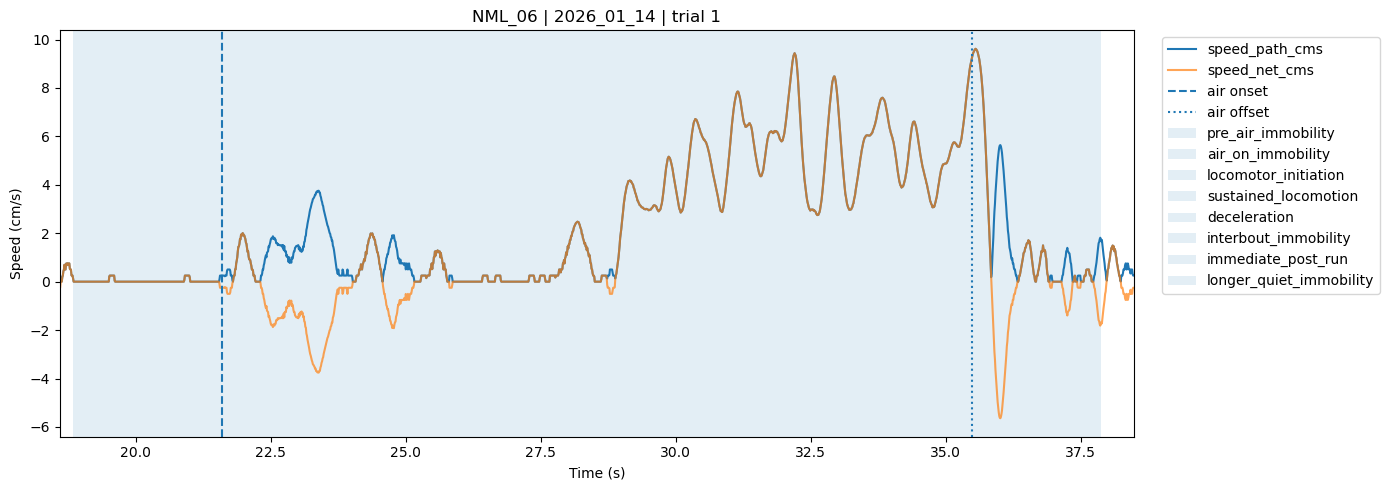

In [18]:
fig, ax = pbs.plot_behavior_state_trial(
    trial=1,
    trial_summary_df=trial_summary_df,
    state_episodes_df=state_episodes_df,
    state_signals=state_signals,
    pre_air_s=3,
    post_air_s=3,
)

plt.show()

In [19]:
# A simple trial
simple_trials = trial_summary_df.loc[
    ~trial_summary_df["complex_trial"],
    "trial",
]

# Trials with pauses or multiple movement bouts
complex_trials = trial_summary_df.loc[
    trial_summary_df["complex_trial"],
    "trial",
]

# Trials where the mouse was already moving at air onset
moving_at_air_trials = trial_summary_df.loc[
    trial_summary_df["moving_at_air_on"],
    "trial",
]

print("Simple trials:", simple_trials.tolist()[:10])
print("Complex trials:", complex_trials.tolist()[:10])
print(
    "Moving at air onset:",
    moving_at_air_trials.tolist()[:10],
)

Simple trials: [3, 5, 6, 7, 8, 9, 12, 14, 15, 16]
Complex trials: [1, 2, 4, 10, 11, 13, 20, 23, 24, 29]
Moving at air onset: [20, 21, 22, 28]


In [3]:
animal = "NML_04"
date = "2026_01_04"
h5_file = pdio.behavior_h5_path(animal, date)
print(h5_file)

# see which keys are stored in the h5 file.
keys = pdio.list_behavior_h5_keys(animal, date)
print(keys)


animal = "NML_05"
date = "2026_01_04"
# Load full behavior file
b = pdio.load_behavior_h5(animal, date)
b.keys()


# Load selected keys (variable) from behavior file.
speed_path_cm = pdio.load_behavior_h5(
    animal,
    date,
    keys="speed_path_cms"
)

speed_path_cm


# from vis.plots import quick_plot_from_h5 as quick_plot

# quick_plot(cc_data, "NML_05", "2026_01_04")


/mnt/pdata/Classical_Conditioning/NML_04/2026_01_04/behavior/behavior_v1.h5
['Air_f', 'Air_r', 'air_bin', 'air_raw', 'bias', 'countsPerRev', 'dist_net_cm', 'dist_path_cm', 'encoderCount', 'fs', 'number_of_samples', 'si', 'speed_net_cms', 'speed_path_cms', 'speed_window_ms', 't', 'tm', 'trial_forward_cm']


{'speed_path_cms': array([1.00530965, 1.00530965, 1.00530965, ..., 0.        , 0.        ,
        0.        ])}

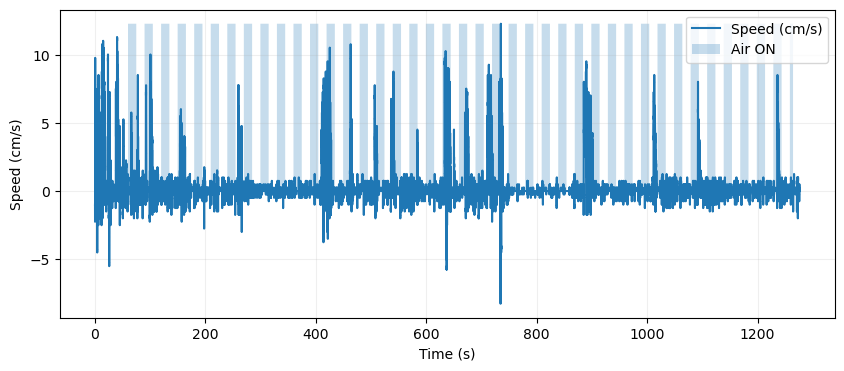

In [5]:
import numpy as np
import matplotlib.pyplot as plt

keys = [
        "t",
        "speed_net_cms",
        "air_bin",
    ]

b = pdio.load_behavior_h5(
        animal,
        date,
        keys=keys
    )

t = b["t"]
speed = b["speed_net_cms"]
air = b["air_bin"].astype(float)

fig, ax = plt.subplots(figsize=(10, 4))

 # -----------------------------
# Plot speed
# -----------------------------
ax.plot(t, speed, linewidth=1.5, label="Speed (cm/s)")

# -----------------------------
# Air shading
# -----------------------------
ymax = np.nanmax(speed) if np.nanmax(speed) > 0 else 1

ax.fill_between(
    t,
    0,
    air * ymax,
    alpha=0.25,
    label="Air ON"
)

# -----------------------------
# Labels
# -----------------------------
ax.set_xlabel("Time (s)")
ax.set_ylabel("Speed (cm/s)")

ax.legend()
ax.grid(alpha=0.2)



Defining the Behavioral State Analysis Code

In [6]:
from __future__ import annotations

from dataclasses import dataclass, asdict
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# =============================================================================
# Configuration
# =============================================================================

@dataclass
class StateConfig:
    """
    Starting parameters for encoder-based behavioral-state segmentation.

    All duration parameters are in seconds.
    All speed thresholds are in cm/s.
    """

    # Downsample the 5,000-Hz signals for behavioral-state analysis.
    # The original sample indices are retained in the output tables.
    analysis_hz: float = 100.0

    # Locomotion detection uses hysteresis:
    # locomotion begins above move_on_cms and ends below move_off_cms.
    move_on_cms: float = 1.0
    move_off_cms: float = 0.5

    # Remove very short movement events and join short movement gaps.
    min_locomotion_s: float = 0.10
    max_locomotion_gap_s: float = 0.30

    # Quiet-immobility definition.
    quiet_threshold_cms: float = 0.25
    min_quiet_s: float = 1.00
    max_quiet_gap_s: float = 0.10

    # Maximum pre-air period assigned to pre-air immobility.
    pre_air_max_s: float = 5.0

    # Provisional encoder-based immediate post-run period.
    # Videography can later refine this boundary.
    immediate_post_run_s: float = 1.0

    # A locomotor bout is separated into:
    # initiation -> sustained locomotion -> deceleration.
    sustain_fraction: float = 0.60
    min_sustain_s: float = 0.20
    max_sustain_gap_s: float = 0.20


# =============================================================================
# General helper functions
# =============================================================================

def find_runs(mask: np.ndarray) -> list[tuple[int, int]]:
    """
    Return contiguous True runs as half-open intervals [start, end).

    Example:
        [False, True, True, False] -> [(1, 3)]
    """
    mask = np.asarray(mask, dtype=bool)

    transitions = np.diff(
        np.r_[False, mask, False].astype(np.int8)
    )

    starts = np.flatnonzero(transitions == 1)
    ends = np.flatnonzero(transitions == -1)

    return [(int(start), int(end)) for start, end in zip(starts, ends)]


def fill_short_false_gaps(
    mask: np.ndarray,
    maximum_gap_samples: int,
) -> np.ndarray:
    """
    Fill short False gaps surrounded by True values.
    """
    output = np.asarray(mask, dtype=bool).copy()

    if maximum_gap_samples <= 0:
        return output

    for start, end in find_runs(~output):
        gap_is_internal = start > 0 and end < len(output)
        gap_is_short = (end - start) <= maximum_gap_samples

        if gap_is_internal and gap_is_short:
            output[start:end] = True

    return output


def remove_short_true_runs(
    mask: np.ndarray,
    minimum_run_samples: int,
) -> np.ndarray:
    """
    Remove True runs shorter than the required duration.
    """
    output = np.asarray(mask, dtype=bool).copy()

    for start, end in find_runs(output):
        if (end - start) < minimum_run_samples:
            output[start:end] = False

    return output


def hysteresis_movement_mask(
    speed: np.ndarray,
    onset_threshold: float,
    offset_threshold: float,
) -> np.ndarray:
    """
    Detect movement using separate onset and offset thresholds.

    Movement begins when:
        speed >= onset_threshold

    Movement ends when:
        speed <= offset_threshold
    """
    if offset_threshold > onset_threshold:
        raise ValueError(
            "offset_threshold must be less than or equal to onset_threshold."
        )

    moving = np.zeros(len(speed), dtype=bool)
    currently_moving = False

    for index, value in enumerate(speed):

        if not currently_moving and value >= onset_threshold:
            currently_moving = True

        elif currently_moving and value <= offset_threshold:
            currently_moving = False

        moving[index] = currently_moving

    return moving


def downsample_block_mean(
    dataset: h5py.Dataset,
    block_size: int,
    number_of_blocks: int,
) -> np.ndarray:
    """
    Downsample an HDF5 dataset using nonoverlapping block means.
    """
    number_of_samples = number_of_blocks * block_size

    values = np.asarray(dataset[:number_of_samples])

    return values.reshape(
        number_of_blocks,
        block_size,
    ).mean(axis=1)


# =============================================================================
# State-specific helper functions
# =============================================================================

def make_episode_row(
    animal: str,
    trial: int,
    state: str,
    start_ds: int,
    end_ds: int,
    air_on_ds: int,
    block_size: int,
    fs: float,
    bout_number: float | int = np.nan,
    notes: str = "",
) -> dict | None:
    """
    Construct one row for the state-episodes table.

    Intervals are represented as:
        [onset, offset)

    Therefore:
        duration = offset - onset
    """
    if start_ds is None or end_ds is None:
        return None

    if end_ds < start_ds:
        return None

    onset_sample = int(start_ds * block_size)
    offset_sample = int(end_ds * block_size)

    return {
        "animal": animal,
        "trial": int(trial),
        "state": state,
        "bout_number": bout_number,

        "onset_sample": onset_sample,
        "offset_sample": offset_sample,

        "onset_s": onset_sample / fs,
        "offset_s": offset_sample / fs,
        "duration_s": (offset_sample - onset_sample) / fs,

        "onset_relative_air_s": (
            (start_ds - air_on_ds) * block_size / fs
        ),
        "offset_relative_air_s": (
            (end_ds - air_on_ds) * block_size / fs
        ),

        "notes": notes,
    }


def split_locomotor_bout(
    speed_path_ds: np.ndarray,
    start: int,
    end: int,
    config: StateConfig,
) -> dict:
    """
    Split one locomotor bout into:

        locomotor initiation
        sustained locomotion
        deceleration

    The sustained-speed threshold is calculated separately for each bout:

        threshold = max(
            move_on_cms,
            sustain_fraction * 75th percentile bout speed
        )
    """
    bout_speed = speed_path_ds[start:end]

    if len(bout_speed) == 0:
        return {
            "initiation": None,
            "sustained": None,
            "deceleration": None,
            "cruise_speed_cms": np.nan,
            "sustain_threshold_cms": np.nan,
            "status": "empty_bout",
        }

    cruise_speed = float(np.percentile(bout_speed, 75))

    sustain_threshold = max(
        config.move_on_cms,
        config.sustain_fraction * cruise_speed,
    )

    sustained_mask = bout_speed >= sustain_threshold

    sustained_mask = fill_short_false_gaps(
        sustained_mask,
        round(
            config.max_sustain_gap_s *
            config.analysis_hz
        ),
    )

    sustained_mask = remove_short_true_runs(
        sustained_mask,
        max(
            1,
            round(
                config.min_sustain_s *
                config.analysis_hz
            ),
        ),
    )

    sustained_runs = find_runs(sustained_mask)

    # If no stable sustained period is found, use the speed peak
    # to separate initiation from deceleration.
    if not sustained_runs:
        peak_index = int(np.argmax(bout_speed))
        split_index = start + peak_index + 1

        return {
            "initiation": (start, split_index),
            "sustained": None,
            "deceleration": (split_index, end),
            "cruise_speed_cms": cruise_speed,
            "sustain_threshold_cms": sustain_threshold,
            "status": "no_sustained_phase",
        }

    sustained_start = start + sustained_runs[0][0]
    sustained_end = start + sustained_runs[-1][1]

    return {
        "initiation": (start, sustained_start),
        "sustained": (sustained_start, sustained_end),
        "deceleration": (sustained_end, end),
        "cruise_speed_cms": cruise_speed,
        "sustain_threshold_cms": sustain_threshold,
        "status": "ok",
    }


# =============================================================================
# Main analysis function
# =============================================================================

def identify_behavior_states(
    h5_path: str | Path,
    animal_id: str | None = None,
    config: StateConfig | None = None,
):
    """
    Identify behavioral states from one behavior H5 file.

    Returns
    -------
    trial_summary_df
        One row per air trial.

    state_episodes_df
        One row per behavioral-state episode.

    locomotor_bouts_df
        One row per locomotor bout.

    signals
        Downsampled signals and masks used for plotting and quality control.
    """

    if config is None:
        config = StateConfig()

    h5_path = Path(h5_path)

    if animal_id is None:
        animal_id = h5_path.stem

    # -------------------------------------------------------------------------
    # Load the required variables
    # -------------------------------------------------------------------------

    with h5py.File(h5_path, "r") as h5_file:

        required_variables = [
            "fs",
            "number_of_samples",
            "Air_r",
            "Air_f",
            "speed_path_cms",
            "speed_net_cms",
        ]

        missing_variables = [
            variable
            for variable in required_variables
            if variable not in h5_file
        ]

        if missing_variables:
            raise KeyError(
                f"Missing variables in H5 file: {missing_variables}"
            )

        fs = float(h5_file["fs"][()])
        number_of_samples = int(
            h5_file["number_of_samples"][()]
        )

        # Air_r is the first high sample.
        air_on_samples = np.asarray(
            h5_file["Air_r"][:],
            dtype=np.int64,
        )

        # Air_f is the final high sample, so add 1 to represent
        # the first air-off sample.
        air_off_samples = (
            np.asarray(
                h5_file["Air_f"][:],
                dtype=np.int64,
            ) + 1
        )

        if "trial_forward_cm" in h5_file:
            trial_forward_cm = np.asarray(
                h5_file["trial_forward_cm"][:],
                dtype=float,
            )
        else:
            trial_forward_cm = np.full(
                len(air_on_samples),
                np.nan,
            )

        # Determine an integer downsampling block.
        block_size = max(
            1,
            int(round(fs / config.analysis_hz)),
        )

        actual_analysis_hz = fs / block_size

        if not np.isclose(
            actual_analysis_hz,
            config.analysis_hz,
        ):
            config = StateConfig(
                **{
                    **asdict(config),
                    "analysis_hz": actual_analysis_hz,
                }
            )

        number_of_blocks = (
            number_of_samples // block_size
        )

        speed_path_ds = downsample_block_mean(
            h5_file["speed_path_cms"],
            block_size,
            number_of_blocks,
        )

        speed_net_ds = downsample_block_mean(
            h5_file["speed_net_cms"],
            block_size,
            number_of_blocks,
        )

    # -------------------------------------------------------------------------
    # Detect gross locomotion
    # -------------------------------------------------------------------------

    moving_mask = hysteresis_movement_mask(
        speed=speed_path_ds,
        onset_threshold=config.move_on_cms,
        offset_threshold=config.move_off_cms,
    )

    # Join brief interruptions in an otherwise continuous bout.
    moving_mask = fill_short_false_gaps(
        moving_mask,
        round(
            config.max_locomotion_gap_s *
            config.analysis_hz
        ),
    )

    # Remove very short movement events.
    moving_mask = remove_short_true_runs(
        moving_mask,
        max(
            1,
            round(
                config.min_locomotion_s *
                config.analysis_hz
            ),
        ),
    )

    locomotor_runs = find_runs(moving_mask)

    # -------------------------------------------------------------------------
    # Detect longer quiet-immobility periods
    # -------------------------------------------------------------------------

    quiet_mask = (
        speed_path_ds <= config.quiet_threshold_cms
    )

    quiet_mask = fill_short_false_gaps(
        quiet_mask,
        round(
            config.max_quiet_gap_s *
            config.analysis_hz
        ),
    )

    quiet_mask = remove_short_true_runs(
        quiet_mask,
        max(
            1,
            round(
                config.min_quiet_s *
                config.analysis_hz
            ),
        ),
    )

    quiet_runs = find_runs(quiet_mask)

    # Convert air events to downsampled indices.
    air_on_ds = (
        air_on_samples // block_size
    ).astype(int)

    air_off_ds = np.ceil(
        air_off_samples / block_size
    ).astype(int)

    state_rows = []
    summary_rows = []
    bout_rows = []

    # -------------------------------------------------------------------------
    # Process each air trial
    # -------------------------------------------------------------------------

    for trial_index, (air_on, air_off) in enumerate(
        zip(air_on_ds, air_off_ds),
        start=1,
    ):
        previous_boundary = (
            air_off_ds[trial_index - 2]
            if trial_index > 1
            else 0
        )

        next_air_on = (
            air_on_ds[trial_index]
            if trial_index < len(air_on_ds)
            else number_of_blocks
        )

        # =====================================================================
        # 1. Pre-air immobility
        # =====================================================================

        pre_air_limit = max(
            previous_boundary,
            air_on - round(
                config.pre_air_max_s *
                config.analysis_hz
            ),
        )

        pre_air_candidates = [
            (start, end)
            for start, end in quiet_runs
            if end >= air_on and start < air_on
        ]

        if pre_air_candidates:
            quiet_start, _ = pre_air_candidates[-1]

            pre_air_start = max(
                quiet_start,
                pre_air_limit,
            )

            pre_air_end = air_on

        else:
            pre_air_start = air_on
            pre_air_end = air_on

        state_rows.append(
            make_episode_row(
                animal=animal_id,
                trial=trial_index,
                state="pre_air_immobility",
                start_ds=pre_air_start,
                end_ds=pre_air_end,
                air_on_ds=air_on,
                block_size=block_size,
                fs=fs,
            )
        )

        # =====================================================================
        # Find all locomotor bouts intersecting the air-on interval
        # =====================================================================

        response_bouts = [
            (start, end)
            for start, end in locomotor_runs
            if end > air_on and start < air_off
        ]

        response_bouts.sort()

        # =====================================================================
        # 2. Air presented while still immobile
        # =====================================================================

        if response_bouts:
            first_locomotor_start = response_bouts[0][0]

            air_immobility_end = max(
                air_on,
                min(first_locomotor_start, air_off),
            )

        else:
            first_locomotor_start = None
            air_immobility_end = air_off

        state_rows.append(
            make_episode_row(
                animal=animal_id,
                trial=trial_index,
                state="air_on_immobility",
                start_ds=air_on,
                end_ds=air_immobility_end,
                air_on_ds=air_on,
                block_size=block_size,
                fs=fs,
            )
        )

        initiation_total_s = 0.0
        sustained_total_s = 0.0
        deceleration_total_s = 0.0

        # =====================================================================
        # 3–5. Initiation, sustained locomotion, and deceleration
        # =====================================================================

        for bout_number, (
            bout_start,
            bout_end,
        ) in enumerate(response_bouts, start=1):

            bout_split = split_locomotor_bout(
                speed_path_ds=speed_path_ds,
                start=bout_start,
                end=bout_end,
                config=config,
            )

            bout_rows.append(
                {
                    "animal": animal_id,
                    "trial": trial_index,
                    "bout_number": bout_number,

                    "onset_sample": (
                        bout_start * block_size
                    ),
                    "offset_sample": (
                        bout_end * block_size
                    ),

                    "onset_s": (
                        bout_start * block_size / fs
                    ),
                    "offset_s": (
                        bout_end * block_size / fs
                    ),
                    "duration_s": (
                        (bout_end - bout_start) *
                        block_size / fs
                    ),

                    "overlap_with_air_s": (
                        max(
                            0,
                            min(bout_end, air_off) -
                            max(bout_start, air_on),
                        ) *
                        block_size / fs
                    ),

                    "mean_speed_path_cms": float(
                        np.mean(
                            speed_path_ds[
                                bout_start:bout_end
                            ]
                        )
                    ),

                    "peak_speed_path_cms": float(
                        np.max(
                            speed_path_ds[
                                bout_start:bout_end
                            ]
                        )
                    ),

                    "mean_speed_net_cms": float(
                        np.mean(
                            speed_net_ds[
                                bout_start:bout_end
                            ]
                        )
                    ),

                    "cruise_speed_cms": (
                        bout_split[
                            "cruise_speed_cms"
                        ]
                    ),

                    "sustain_threshold_cms": (
                        bout_split[
                            "sustain_threshold_cms"
                        ]
                    ),

                    "split_status": (
                        bout_split["status"]
                    ),
                }
            )

            state_mapping = [
                (
                    "locomotor_initiation",
                    "initiation",
                ),
                (
                    "sustained_locomotion",
                    "sustained",
                ),
                (
                    "deceleration",
                    "deceleration",
                ),
            ]

            for state_name, split_name in state_mapping:

                interval = bout_split[split_name]

                if interval is None:
                    continue

                state_start, state_end = interval

                if state_end <= state_start:
                    continue

                row = make_episode_row(
                    animal=animal_id,
                    trial=trial_index,
                    state=state_name,
                    start_ds=state_start,
                    end_ds=state_end,
                    air_on_ds=air_on,
                    block_size=block_size,
                    fs=fs,
                    bout_number=bout_number,
                    notes=bout_split["status"],
                )

                state_rows.append(row)

                if state_name == "locomotor_initiation":
                    initiation_total_s += row["duration_s"]

                elif state_name == "sustained_locomotion":
                    sustained_total_s += row["duration_s"]

                elif state_name == "deceleration":
                    deceleration_total_s += row["duration_s"]

        # =====================================================================
        # Immobility between locomotor bouts
        # =====================================================================

        for bout_index in range(
            len(response_bouts) - 1
        ):
            gap_start = response_bouts[bout_index][1]
            gap_end = response_bouts[bout_index + 1][0]

            if gap_end > gap_start:
                state_rows.append(
                    make_episode_row(
                        animal=animal_id,
                        trial=trial_index,
                        state="interbout_immobility",
                        start_ds=gap_start,
                        end_ds=gap_end,
                        air_on_ds=air_on,
                        block_size=block_size,
                        fs=fs,
                        bout_number=bout_index + 1,
                    )
                )

        # =====================================================================
        # 6. Immediate post-run period
        # =====================================================================

        if response_bouts:
            final_locomotor_offset = (
                response_bouts[-1][1]
            )

            immediate_post_end = min(
                next_air_on,
                final_locomotor_offset +
                round(
                    config.immediate_post_run_s *
                    config.analysis_hz
                ),
            )

            state_rows.append(
                make_episode_row(
                    animal=animal_id,
                    trial=trial_index,
                    state="immediate_post_run",
                    start_ds=final_locomotor_offset,
                    end_ds=immediate_post_end,
                    air_on_ds=air_on,
                    block_size=block_size,
                    fs=fs,
                )
            )

            # =================================================================
            # 7. Longer quiet immobility
            # =================================================================

            quiet_candidates = [
                (start, end)
                for start, end in quiet_runs
                if end > immediate_post_end
                and start < next_air_on
            ]

            if quiet_candidates:
                quiet_start, quiet_end = (
                    quiet_candidates[0]
                )

                longer_quiet_start = max(
                    quiet_start,
                    immediate_post_end,
                )

                longer_quiet_end = min(
                    quiet_end,
                    next_air_on,
                )

                if longer_quiet_end > longer_quiet_start:
                    state_rows.append(
                        make_episode_row(
                            animal=animal_id,
                            trial=trial_index,
                            state=(
                                "longer_quiet_immobility"
                            ),
                            start_ds=longer_quiet_start,
                            end_ds=longer_quiet_end,
                            air_on_ds=air_on,
                            block_size=block_size,
                            fs=fs,
                        )
                    )

                else:
                    longer_quiet_start = None
                    longer_quiet_end = None

            else:
                longer_quiet_start = None
                longer_quiet_end = None

        else:
            final_locomotor_offset = None
            immediate_post_end = None
            longer_quiet_start = None
            longer_quiet_end = None

        # =====================================================================
        # Trial-level summary
        # =====================================================================

        total_locomotion_during_air_s = (
            sum(
                max(
                    0,
                    min(end, air_off) -
                    max(start, air_on),
                )
                for start, end in response_bouts
            ) *
            block_size / fs
        )

        if first_locomotor_start is not None:
            locomotor_onset_sample = (
                first_locomotor_start *
                block_size
            )

            locomotor_onset_s = (
                locomotor_onset_sample / fs
            )

            air_to_locomotion_latency_s = (
                (first_locomotor_start - air_on) *
                block_size / fs
            )

        else:
            locomotor_onset_sample = np.nan
            locomotor_onset_s = np.nan
            air_to_locomotion_latency_s = np.nan

        if final_locomotor_offset is not None:
            locomotor_offset_sample = (
                final_locomotor_offset *
                block_size
            )

            locomotor_offset_s = (
                locomotor_offset_sample / fs
            )

            continued_running_after_air_off_s = (
                max(
                    0,
                    final_locomotor_offset -
                    air_off,
                ) *
                block_size / fs
            )

            immediate_post_duration_s = (
                (
                    immediate_post_end -
                    final_locomotor_offset
                ) *
                block_size / fs
            )

        else:
            locomotor_offset_sample = np.nan
            locomotor_offset_s = np.nan
            continued_running_after_air_off_s = np.nan
            immediate_post_duration_s = np.nan

        if longer_quiet_start is not None:
            longer_quiet_onset_s = (
                longer_quiet_start *
                block_size / fs
            )

            longer_quiet_offset_s = (
                longer_quiet_end *
                block_size / fs
            )

            longer_quiet_duration_s = (
                (
                    longer_quiet_end -
                    longer_quiet_start
                ) *
                block_size / fs
            )

        else:
            longer_quiet_onset_s = np.nan
            longer_quiet_offset_s = np.nan
            longer_quiet_duration_s = np.nan

        summary_rows.append(
            {
                "animal": animal_id,
                "trial": trial_index,

                "air_on_sample": int(
                    air_on_samples[
                        trial_index - 1
                    ]
                ),

                "air_off_sample": int(
                    air_off_samples[
                        trial_index - 1
                    ]
                ),

                "air_on_s": (
                    air_on_samples[
                        trial_index - 1
                    ] / fs
                ),

                "air_off_s": (
                    air_off_samples[
                        trial_index - 1
                    ] / fs
                ),

                "air_duration_s": (
                    (
                        air_off_samples[
                            trial_index - 1
                        ] -
                        air_on_samples[
                            trial_index - 1
                        ]
                    ) / fs
                ),

                "trial_forward_cm": (
                    trial_forward_cm[
                        trial_index - 1
                    ]
                ),

                "pre_air_immobility_duration_s": (
                    (
                        pre_air_end -
                        pre_air_start
                    ) *
                    block_size / fs
                ),

                "air_on_immobility_duration_s": (
                    (
                        air_immobility_end -
                        air_on
                    ) *
                    block_size / fs
                ),

                "first_locomotor_onset_sample": (
                    locomotor_onset_sample
                ),

                "first_locomotor_onset_s": (
                    locomotor_onset_s
                ),

                "air_to_locomotion_latency_s": (
                    air_to_locomotion_latency_s
                ),

                "final_locomotor_offset_sample": (
                    locomotor_offset_sample
                ),

                "final_locomotor_offset_s": (
                    locomotor_offset_s
                ),

                "continued_running_after_air_off_s": (
                    continued_running_after_air_off_s
                ),

                "n_locomotor_bouts": len(
                    response_bouts
                ),

                "total_locomotion_during_air_s": (
                    total_locomotion_during_air_s
                ),

                "initiation_total_s": (
                    initiation_total_s
                ),

                "sustained_locomotion_total_s": (
                    sustained_total_s
                ),

                "deceleration_total_s": (
                    deceleration_total_s
                ),

                "immediate_post_run_duration_s": (
                    immediate_post_duration_s
                ),

                "longer_quiet_immobility_onset_s": (
                    longer_quiet_onset_s
                ),

                "longer_quiet_immobility_offset_s": (
                    longer_quiet_offset_s
                ),

                "longer_quiet_immobility_duration_s": (
                    longer_quiet_duration_s
                ),

                "moving_at_air_on": bool(
                    moving_mask[air_on]
                ),

                "no_locomotor_response": (
                    len(response_bouts) == 0
                ),

                "complex_trial": (
                    len(response_bouts) > 1
                ),
            }
        )

    # Remove any None rows caused by zero-duration states.
    state_rows = [
        row for row in state_rows
        if row is not None
    ]

    trial_summary_df = pd.DataFrame(
        summary_rows
    )

    state_episodes_df = pd.DataFrame(
        state_rows
    ).sort_values(
        ["trial", "onset_sample", "state"]
    ).reset_index(drop=True)

    locomotor_bouts_df = pd.DataFrame(
        bout_rows
    ).sort_values(
        ["trial", "bout_number"]
    ).reset_index(drop=True)

    signals = {
        "fs": fs,
        "block_size": block_size,
        "analysis_hz": config.analysis_hz,

        "speed_path_cms": speed_path_ds,
        "speed_net_cms": speed_net_ds,

        "moving_mask": moving_mask,
        "quiet_mask": quiet_mask,

        "air_on_ds": air_on_ds,
        "air_off_ds": air_off_ds,

        "config": config,
    }

    return (
        trial_summary_df,
        state_episodes_df,
        locomotor_bouts_df,
        signals,
    )


# =============================================================================
# Diagnostic plot
# =============================================================================

def plot_behavior_trial(
    trial: int,
    trial_summary_df: pd.DataFrame,
    state_episodes_df: pd.DataFrame,
    signals: dict,
    pre_air_s: float = 3.0,
    post_air_s: float = 3.0,
):
    """
    Plot speed, air timing, and detected states for one trial.
    """

    trial_row = trial_summary_df.loc[
        trial_summary_df["trial"] == trial
    ]

    if trial_row.empty:
        raise ValueError(
            f"Trial {trial} was not found."
        )

    trial_row = trial_row.iloc[0]

    analysis_hz = signals["analysis_hz"]
    speed_path = signals["speed_path_cms"]
    speed_net = signals["speed_net_cms"]

    air_on = trial_row["air_on_s"]
    air_off = trial_row["air_off_s"]

    plot_start_s = max(
        0,
        air_on - pre_air_s,
    )

    plot_end_s = min(
        len(speed_path) / analysis_hz,
        air_off + post_air_s,
    )

    start_index = int(
        np.floor(
            plot_start_s * analysis_hz
        )
    )

    end_index = int(
        np.ceil(
            plot_end_s * analysis_hz
        )
    )

    time = (
        np.arange(start_index, end_index) /
        analysis_hz
    )

    figure, axis = plt.subplots(
        figsize=(14, 6)
    )

    axis.plot(
        time,
        speed_path[start_index:end_index],
        label="Path speed",
    )

    axis.plot(
        time,
        speed_net[start_index:end_index],
        label="Net speed",
        alpha=0.75,
    )

    axis.axvline(
        air_on,
        linestyle="--",
        label="Air onset",
    )

    axis.axvline(
        air_off,
        linestyle=":",
        label="Air offset",
    )

    trial_states = state_episodes_df.loc[
        state_episodes_df["trial"] == trial
    ].copy()

    default_colors = plt.rcParams[
        "axes.prop_cycle"
    ].by_key()["color"]

    state_names = list(
        trial_states["state"].unique()
    )

    state_color = {
        state: default_colors[
            index % len(default_colors)
        ]
        for index, state in enumerate(
            state_names
        )
    }

    already_labeled = set()

    for _, state_row in trial_states.iterrows():

        state = state_row["state"]

        label = (
            state
            if state not in already_labeled
            else None
        )

        axis.axvspan(
            state_row["onset_s"],
            state_row["offset_s"],
            alpha=0.12,
            color=state_color[state],
            label=label,
        )

        already_labeled.add(state)

    axis.set_xlim(
        plot_start_s,
        plot_end_s,
    )

    axis.set_xlabel("Time (s)")
    axis.set_ylabel("Speed (cm/s)")

    axis.set_title(
        f"Behavioral-state segmentation: trial {trial}"
    )

    axis.legend(
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
    )

    figure.tight_layout()

    return figure, axis

Running Analysis

In [ ]:
h5_path = "behavior_v1.h5"

config = StateConfig(
    analysis_hz=100,

    move_on_cms=1.0,
    move_off_cms=0.5,

    min_locomotion_s=0.10,
    max_locomotion_gap_s=0.30,

    quiet_threshold_cms=0.25,
    min_quiet_s=1.0,

    immediate_post_run_s=1.0,

    sustain_fraction=0.60,
)

(
    trial_summary_df,
    state_episodes_df,
    locomotor_bouts_df,
    signals,
) = identify_behavior_states(
    h5_path=h5_path,
    animal_id="Animal_1",
    config=config,
)